In [2]:
import numpy as np
import pandas as pd
import scipy.stats as scs
import matplotlib.pyplot as plt
from scipy.stats import norm

In [48]:
def CF(phi, P0, kappa, theta, lam, sigma, v, rho, T, t, r):

    if phi == 0:
        phi = 1e-15

    tau = T - t
    x = np.log(P0)

    i = 1j
    a = kappa * theta

    u = [0.5, -0.5]
    b = [kappa + lam - rho * sigma, kappa + lam]

    f = []

    for uj, bj in zip(u, b):

        d = np.sqrt(
            (rho * sigma * phi * i - bj) ** 2
            - sigma**2 * (2 * uj * phi * i - phi**2)
        )

        g = (bj - rho * sigma * phi * i - d) / (bj - rho * sigma * phi * i + d)

        C = (
            r * phi * i * tau
            + (a / sigma**2)
            * (
                (bj - rho * sigma * phi * i - d) * tau
                - 2 * np.log((1 - g * np.exp(-d * tau)) / (1 - g))
            )
        )

        D = ((bj - rho * sigma * phi * i - d) / sigma**2) * (
            (1 - np.exp(-d * tau)) / (1 - g * np.exp(-d * tau))
        )

        f.append(np.exp(C + D * v + i * phi * x))

    return f

In [50]:
from scipy.integrate import quad

def Pj(K, f):

    probs = []

    for cf in f:

        integrand = lambda phi: np.real(
            np.exp(-1j * phi * np.log(K)) * cf(phi) / (1j * phi)
        )

        value = 0.5 + (1 / np.pi) * quad(integrand, 1e-8, np.inf)[0]

        probs.append(value)

    return probs[0], probs[1]

In [49]:
def HestonCall(P0, K, r, T, t, kappa, theta, lam, sigma, v, rho):

    f1 = lambda phi: CF(phi, P0, kappa, theta, lam, sigma, v, rho, T, t, r)[0]
    f2 = lambda phi: CF(phi, P0, kappa, theta, lam, sigma, v, rho, T, t, r)[1]

    P1, P2 = Pj(K, [f1, f2])

    return P0 * P1 - K * np.exp(-r * (T - t)) * P2

In [35]:
kappa = 2
theta = 0.01
lam = 0
v = 0.01
rho = 0
sigma = 0.1
P0 = 80
T = 5
t = 0
r = 0
K = 100

In [53]:
HestonCall(P0, K, r, T, t, kappa, theta, lam, sigma, v, rho)

np.float64(9.406344534178132)

In [54]:
def simulate_heston(P0, v0, r, kappa, theta, sigma, rho, T, n_steps, n_paths):

    dt = T / n_steps

    S = np.zeros((n_steps + 1, n_paths))
    v = np.zeros((n_steps + 1, n_paths))

    S[0] = P0
    v[0] = v0

    for t in range(n_steps):
        Z1 = np.random.normal(0, 1, n_paths)
        Z2 = np.random.normal(0, 1, n_paths)

        #Correlate BMs
        Zv = Z1
        ZS = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        v_pos = np.maximum(v[t], 0)

        v[t + 1] = v[t] + kappa * (theta - v_pos) * dt + sigma * np.sqrt(
            v_pos * dt
        ) * Zv

        log_S_next = (
            np.log(S[t])
            + (r - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * ZS
        )
        S[t + 1] = np.exp(log_S_next)

    return S, v

In [55]:
# Model Parameters (same as your analytical test)
P0 = 100.0
K = 100.0
r = 0.05
T = 1.0
kappa = 2.0
theta = 0.04
sigma = 0.5
v0 = 0.04
rho = -0.7

# 1. Run Monte Carlo Simulation
np.random.seed(42)
n_steps = 250  # ~Daily steps over 1 year
n_paths = 50_000  # Number of simulated trajectories

S_paths, v_paths = simulate_heston(
    P0, v0, r, kappa, theta, sigma, rho, T, n_steps, n_paths
)

# 2. Compute Payoff at Maturity T and Discount to Present
terminal_prices = S_paths[-1]
payoffs = np.maximum(terminal_prices - K, 0)
mc_call_price = np.exp(-r * T) * np.mean(payoffs)

# Standard error of the Monte Carlo estimate
mc_se = np.exp(-r * T) * (np.std(payoffs) / np.sqrt(n_paths))

# 3. Analytical Price (from your previous HestonCall function)
analytical_price = HestonCall(
    P0, K, r, T, 0.0, kappa, theta, 0.0, sigma, v0, rho
)

print(f"Analytical Heston Price : {analytical_price:.4f}")
print(f"Monte Carlo Heston Price: {mc_call_price:.4f}  (±{1.96 * mc_se:.4f})")

Analytical Heston Price : 10.1546
Monte Carlo Heston Price: 10.1787  (±0.0965)


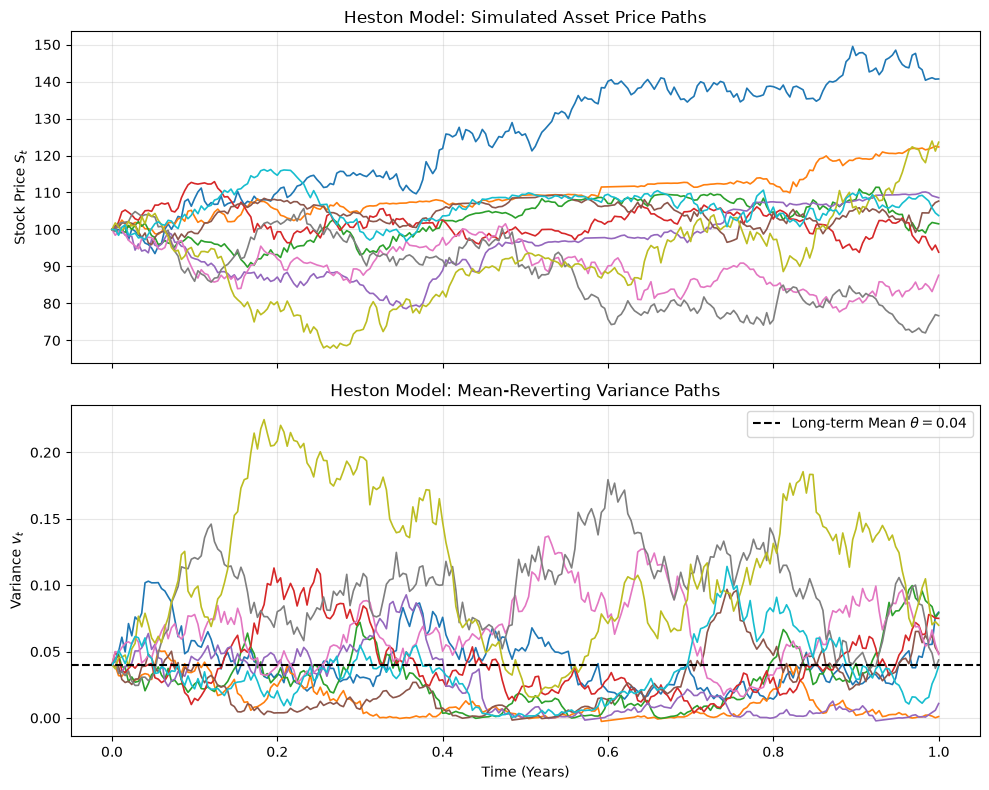

In [56]:
time_grid = np.linspace(0, T, n_steps + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 10 Stock Price Paths
ax1.plot(time_grid, S_paths[:, :10], lw=1.2)
ax1.set_ylabel("Stock Price $S_t$")
ax1.set_title("Heston Model: Simulated Asset Price Paths")
ax1.grid(True, alpha=0.3)

# Plot 10 Variance Paths
ax2.plot(time_grid, v_paths[:, :10], lw=1.2)
ax2.axhline(
    theta,
    color="black",
    linestyle="--",
    lw=1.5,
    label=f"Long-term Mean $\\theta = {theta}$",
)
ax2.set_ylabel("Variance $v_t$")
ax2.set_xlabel("Time (Years)")
ax2.set_title("Heston Model: Mean-Reverting Variance Paths")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from scipy.optimize import brentq
from scipy.stats import norm

# --- 1. Standard Black-Scholes Formula ---


def bs_call_price(S, K, r, T, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


# --- 2. Invert Black-Scholes to Find Implied Volatility ---


def implied_volatility(market_price, S, K, r, T):
    intrinsic = max(S - K * np.exp(-r * T), 0.0)
    if market_price <= intrinsic:
        return np.nan

    # Objective function: find sigma where BS_Price - market_price = 0
    objective = lambda sig: bs_call_price(S, K, r, T, sig) - market_price

    try:
        # Search for implied vol between 0.01% and 500%
        return brentq(objective, 1e-4, 5.0)
    except (ValueError, RuntimeError):
        return np.nan

Calculating Heston Volatility Surface...


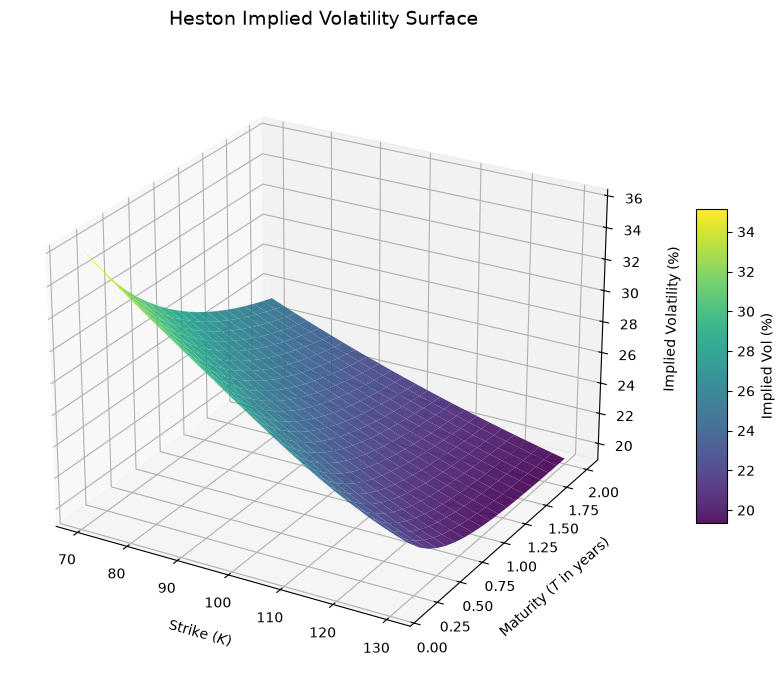

In [60]:
# Model Parameters (Equities typically have rho < 0)
P0 = 100.0  # Spot price
r = 0.03  # 3% risk-free rate
kappa = 2.5  # Mean reversion speed
theta = 0.04  # Long-term variance (20% vol)
v0 = 0.09  # Current variance (30% vol - starting in a high-vol regime!)
sigma = 0.4  # Vol of vol
rho = -0.7  # Strong negative correlation (leverage effect)
lam = 0.0

# 1. Create a grid of Strikes (K) and Maturities (T)
strikes = np.linspace(70, 130, 25)  # From deep ITM to deep OTM
maturities = np.linspace(0.1, 2.0, 20)  # From 1 month to 2 years

K_mesh, T_mesh = np.meshgrid(strikes, maturities)
IV_surface = np.zeros_like(K_mesh)

print("Calculating Heston Volatility Surface...")
for i in range(len(maturities)):
    for j in range(len(strikes)):
        K_val = K_mesh[i, j]
        T_val = T_mesh[i, j]

        # Price using your analytical Heston engine
        heston_price = HestonCall(
            P0, K_val, r, T_val, 0.0, kappa, theta, lam, sigma, v0, rho
        )

        # Invert to Black-Scholes Implied Volatility
        IV_surface[i, j] = implied_volatility(
            heston_price, P0, K_val, r, T_val
        )

# 2. Plotting the 3D Surface
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    K_mesh,
    T_mesh,
    IV_surface * 100,  # Express as percentage (%)
    cmap="viridis",
    edgecolor="none",
    alpha=0.9,
)

ax.set_title("Heston Implied Volatility Surface", fontsize=14, pad=20)
ax.set_xlabel("Strike ($K$)", labelpad=10)
ax.set_ylabel("Maturity ($T$ in years)", labelpad=10)
ax.set_zlabel("Implied Volatility (%)", labelpad=10)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Implied Vol (%)")
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

Fetching options data for TLT...
Current Spot Price: $77.48 | Found 30 expiration dates.
Successfully collected 166 clean option points!


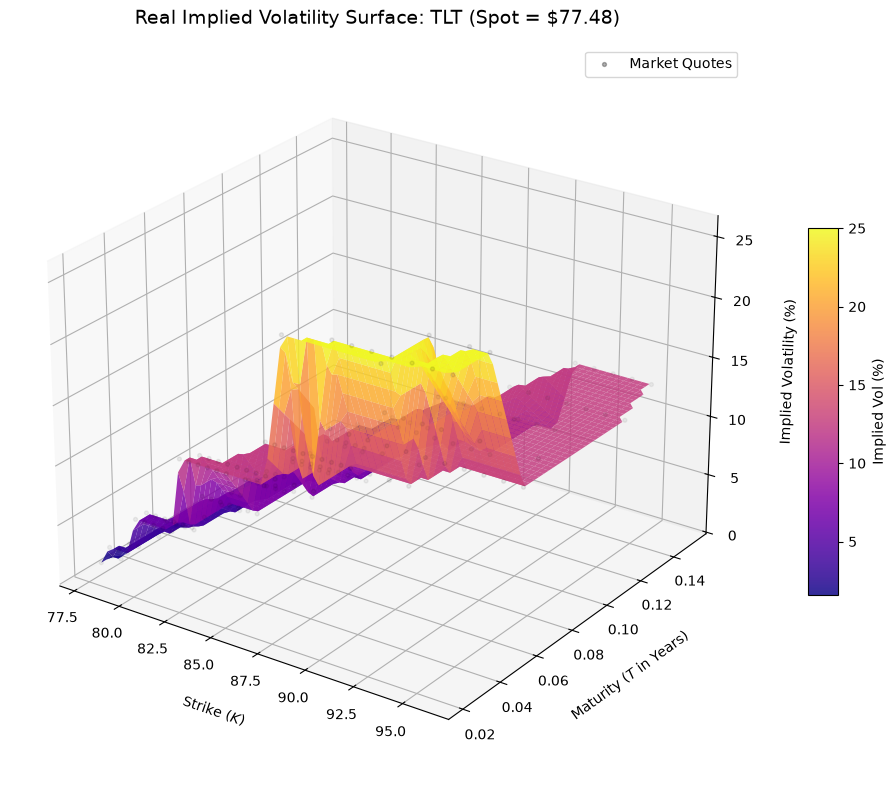

In [67]:
from datetime import datetime
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import yfinance as yf

# ==========================================
# 1. Choose Ticker
# ==========================================
TICKER = "TLT"  # Highly liquid ETF with guaranteed active options

print(f"Fetching options data for {TICKER}...")
stock = yf.Ticker(TICKER)

# Get Spot Price
hist = stock.history(period="5d")
if hist.empty:
    raise ValueError(
        f"Could not fetch price data for {TICKER}. Check ticker symbol or"
        " internet connection."
    )
spot_price = hist["Close"].iloc[-1]

expirations = stock.options
if not expirations:
    raise ValueError(f"No option chains found for {TICKER}.")

print(
    f"Current Spot Price: ${spot_price:.2f} | Found {len(expirations)}"
    " expiration dates."
)

# ==========================================
# 2. Collect and Clean Market Option Chains
# ==========================================
records = []
today = datetime.now()

# Look at the first 10-15 expiration dates
for exp_str in expirations[:12]:
    exp_date = datetime.strptime(exp_str, "%Y-%m-%d")
    T = (exp_date - today).days / 365.25

    if T <= 0.02:  # Skip options expiring in less than ~7 days
        continue

    try:
        opt_chain = stock.option_chain(exp_str)
        calls = opt_chain.calls
    except Exception as e:
        continue

    for _, row in calls.iterrows():
        K = row["strike"]
        iv = row.get("impliedVolatility", np.nan)
        last_price = row.get("lastPrice", 0)

        # Relaxed, robust filters:
        # 1. Option must have traded (lastPrice > 0)
        # 2. Strike within 75% to 125% of current spot
        # 3. Valid, realistic implied volatility (1% to 200%)
        if (
            pd.notna(iv)
            and (0.01 < iv < 2.0)
            and (last_price > 0)
            and (0.75 * spot_price <= K <= 1.25 * spot_price)
        ):
            records.append(
                {
                    "Strike": float(K),
                    "Maturity": float(T),
                    "IV": float(iv * 100),  # percentage (%)
                    "Moneyness": float(K / spot_price),
                }
            )

df = pd.DataFrame(records)

# Check if data was successfully collected
if df.empty or len(df) < 20:
    raise ValueError(
        f"Only collected {len(df)} points. Try another ticker like 'SPY', 'QQQ', or 'AAPL'."
    )

print(f"Successfully collected {len(df)} clean option points!")

# ==========================================
# 3. Interpolate onto a Grid
# ==========================================
grid_K = np.linspace(df["Strike"].min(), df["Strike"].max(), 50)
grid_T = np.linspace(df["Maturity"].min(), df["Maturity"].max(), 50)
K_mesh, T_mesh = np.meshgrid(grid_K, grid_T)

# Use linear interpolation first to avoid NaN boundaries, then smooth
IV_mesh = griddata(
    points=(df["Strike"], df["Maturity"]),
    values=df["IV"],
    xi=(K_mesh, T_mesh),
    method="linear",
)

# ==========================================
# 4. Plot the 3D Surface
# ==========================================
fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    K_mesh,
    T_mesh,
    IV_mesh,
    cmap="plasma",
    edgecolor="none",
    alpha=0.85,
    antialiased=True,
)

# Scatter actual market points on top
ax.scatter(
    df["Strike"],
    df["Maturity"],
    df["IV"],
    color="black",
    s=8,
    alpha=0.3,
    label="Market Quotes",
)

ax.set_title(
    f"Real Implied Volatility Surface: {TICKER} (Spot = ${spot_price:.2f})",
    fontsize=14,
    pad=15,
)
ax.set_xlabel("Strike ($K$)", labelpad=12)
ax.set_ylabel("Maturity ($T$ in Years)", labelpad=12)
ax.set_zlabel("Implied Volatility (%)", labelpad=12)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12, label="Implied Vol (%)")
ax.view_init(elev=25, azim=-55)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

[MU] Connecting to live market data...
[MU] Spot Price = $1074.89 | Risk-Free Rate = 3.99% | Found 24 expiries
[MU] Extracted 734 institutional-grade option contracts!
Saved interactive 3D model to 'vol_surface.html'


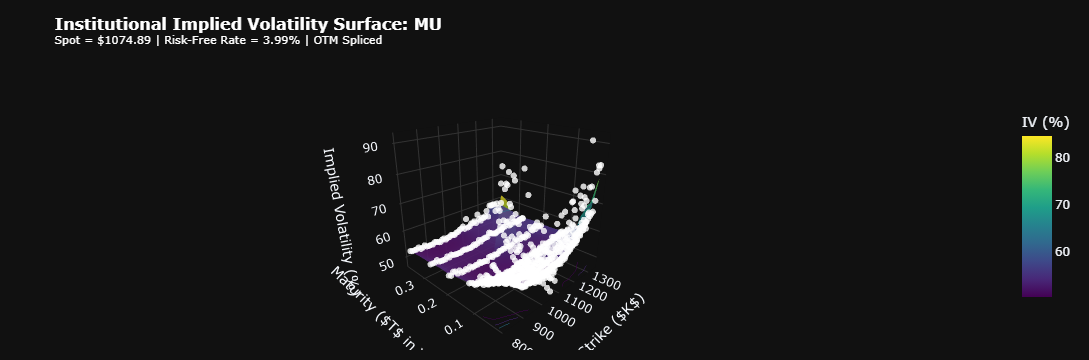

In [71]:
from datetime import datetime
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import Rbf
from scipy.optimize import brentq
from scipy.stats import norm
import yfinance as yf

# =====================================================================
# 1. Configuration & Ticker Setup
# =====================================================================
TICKER = "MU"  # Works with 'TLT', 'SPY', 'QQQ', 'AAPL', 'NVDA', etc.

print(f"[{TICKER}] Connecting to live market data...")
stock = yf.Ticker(TICKER)

# 1.1 Fetch Spot Price
hist = stock.history(period="5d")
if hist.empty:
    raise ValueError(f"Could not retrieve spot price for {TICKER}")
S0 = float(hist["Close"].iloc[-1])

# 1.2 Fetch Live Risk-Free Rate (^IRX: 13-week T-Bill)
try:
    irx = yf.Ticker("^IRX").history(period="5d")["Close"].iloc[-1]
    r = float(irx) / 100.0
except Exception:
    r = 0.045  # Standard ~4.5% fallback

expirations = stock.options
if not expirations:
    raise ValueError(f"No option chains found for {TICKER}.")

print(
    f"[{TICKER}] Spot Price = ${S0:.2f} | Risk-Free Rate = {r*100:.2f}% | Found"
    f" {len(expirations)} expiries"
)

# =====================================================================
# 2. Black-Scholes Numerical IV Inverter
# =====================================================================


def bs_price(S, K, r, T, sigma, option_type="call"):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0) if option_type == "call" else max(K - S, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def invert_iv(target_price, S, K, r, T, option_type):
    disc = np.exp(-r * T)
    intrinsic = (
        max(S - K * disc, 0.0)
        if option_type == "call"
        else max(K * disc - S, 0.0)
    )
    if target_price <= intrinsic:
        return np.nan

    obj = lambda sig: bs_price(S, K, r, T, sig, option_type) - target_price
    try:
        return brentq(obj, 1e-4, 3.5)  # Solves for sigma up to 350%
    except Exception:
        return np.nan


# =====================================================================
# 3. Robust Institutional Data Extraction (With 24/7 Fallbacks)
# =====================================================================
records = []
today = datetime.now()

for exp_str in expirations[:14]:  # First ~1 year of maturities
    exp_date = datetime.strptime(exp_str, "%Y-%m-%d")
    T = (exp_date - today).days / 365.25

    if T < 0.02:  # Skip < 7 days
        continue

    try:
        chain = stock.option_chain(exp_str)
    except Exception:
        continue

    # OTM Splicing: Puts below spot, Calls at/above spot
    otm_puts = chain.puts[chain.puts["strike"] < S0].copy()
    otm_puts["type"] = "put"

    otm_calls = chain.calls[chain.calls["strike"] >= S0].copy()
    otm_calls["type"] = "call"

    combined = pd.concat([otm_puts, otm_calls], ignore_index=True)

    for _, row in combined.iterrows():
        K = float(row["strike"])
        bid = float(row.get("bid", 0.0))
        ask = float(row.get("ask", 0.0))
        last = float(row.get("lastPrice", 0.0))
        stored_iv = float(row.get("impliedVolatility", np.nan))
        opt_type = row["type"]

        # 1. Determine Price: Use Mid if market is open; otherwise fall back to Last
        if bid > 0 and ask > bid:
            price = (bid + ask) / 2.0
            pricing_source = "Mid"
        elif last > 0:
            price = last
            pricing_source = "Last"
        else:
            continue

        # 2. Filter strikes to reasonable liquidity window (75% to 125% of Spot)
        if not (0.75 * S0 <= K <= 1.25 * S0):
            continue

        # 3. Calculate IV: Invert with Black-Scholes, fall back to stored IV
        computed_iv = invert_iv(price, S0, K, r, T, opt_type)
        if pd.isna(computed_iv) or computed_iv <= 0.01:
            computed_iv = stored_iv

        # Final quality check on IV
        if pd.notna(computed_iv) and (0.05 < computed_iv < 2.0):
            records.append(
                {
                    "Strike": K,
                    "Maturity": T,
                    "IV": computed_iv * 100.0,  # in %
                    "Moneyness": K / S0,
                    "Price": price,
                    "Type": opt_type.upper(),
                    "Source": pricing_source,
                }
            )

# Create structured DataFrame
df = pd.DataFrame(
    records,
    columns=[
        "Strike",
        "Maturity",
        "IV",
        "Moneyness",
        "Price",
        "Type",
        "Source",
    ],
)

if len(df) < 15:
    raise ValueError(
        f"Only captured {len(df)} points. Ticker '{TICKER}' might not have active options right now."
    )

print(f"[{TICKER}] Extracted {len(df)} institutional-grade option contracts!")

# =====================================================================
# 4. Normalized RBF Surface Interpolation
# =====================================================================
# Create regular evaluation grid
grid_K = np.linspace(df["Strike"].min(), df["Strike"].max(), 50)
grid_T = np.linspace(df["Maturity"].min(), df["Maturity"].max(), 50)
K_mesh, T_mesh = np.meshgrid(grid_K, grid_T)

# Scale coordinates to [-1, 1] range so RBF distances are balanced
k_mean, k_std = df["Strike"].mean(), df["Strike"].std()
t_mean, t_std = df["Maturity"].mean(), df["Maturity"].std()

k_norm = (df["Strike"] - k_mean) / k_std
t_norm = (df["Maturity"] - t_mean) / t_std

K_mesh_norm = (K_mesh - k_mean) / k_std
T_mesh_norm = (T_mesh - t_mean) / t_std

# Smooth Thin-Plate spline
rbf = Rbf(k_norm, t_norm, df["IV"], function="multiquadric", smooth=1.2)
IV_mesh = rbf(K_mesh_norm, T_mesh_norm)

# =====================================================================
# 5. Interactive 3D Plotly Visualization
# =====================================================================
fig = go.Figure()

# 5.1 The Continuous Volatility Surface
fig.add_trace(
    go.Surface(
        x=K_mesh,
        y=T_mesh,
        z=IV_mesh,
        colorscale="Viridis",
        colorbar=dict(title="IV (%)", len=0.7),
        opacity=0.88,
        name="Fitted Vol Surface",
        contours_z=dict(
            show=True,
            usecolormap=True,
            highlightcolor="limegreen",
            project_z=True,
        ),
    )
)

# 5.2 The Real Market Option Contracts (Hover to inspect)
fig.add_trace(
    go.Scatter3d(
        x=df["Strike"],
        y=df["Maturity"],
        z=df["IV"],
        mode="markers",
        marker=dict(size=3.5, color="white", opacity=0.8),
        name="Market Contracts",
        text=[
            f"<b>{t} ({src})</b><br>Strike: ${k:.1f}<br>Expiry: {m:.2f}"
            f" yrs<br>IV: {iv:.2f}%<br>Price: ${p:.2f}"
            for t, src, k, m, iv, p in zip(
                df["Type"],
                df["Source"],
                df["Strike"],
                df["Maturity"],
                df["IV"],
                df["Price"],
            )
        ],
        hoverinfo="text",
    )
)

# 5.3 Institutional Dark Mode Styling
fig.update_layout(
    title=dict(
        text=(
            f"<b>Institutional Implied Volatility Surface: {TICKER}</b><br><sup>Spot"
            f" = ${S0:.2f} | Risk-Free Rate = {r*100:.2f}% | OTM"
            " Spliced</sup>"
        ),
        font=dict(size=16, color="white"),
    ),
    template="plotly_dark",
    scene=dict(
        xaxis=dict(title="Strike ($K$)", gridcolor="#333"),
        yaxis=dict(title="Maturity ($T$ in Years)", gridcolor="#333"),
        zaxis=dict(title="Implied Volatility (%)", gridcolor="#333"),
        camera=dict(eye=dict(x=-1.6, y=-1.6, z=0.9)),
    ),
    margin=dict(l=10, r=10, b=10, t=60),
)

# Save to standalone HTML file you can open in Chrome/Edge
fig.write_html("vol_surface.html")
print("Saved interactive 3D model to 'vol_surface.html'")

# Display in notebook/IDE
fig.show()